<a href="https://colab.research.google.com/github/L1ght6/LabsKSVD/blob/main/%D0%9A%D0%A0_%D0%93%D0%BE%D1%80%D0%B0_%D0%A4%D0%86%D0%A23_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Підсумкова контрольна робота

---
Гора ФІТ3-9

---

Посилання на гітхаб:

Посилання на колаб: https://colab.research.google.com/drive/1xXhLNnV2RGwGF8Fng6xGf3BYDtKlLsBQ?usp=sharing

---

Завдання 1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Прочитайте CSV файл
df_yt = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')

In [3]:
# 2. Виведіть перші п'ять рядків
print(df_yt.head())

   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                     2000000.0   
1           US  

In [4]:
# 3. Виведіть розміри датасету, перевірте наявність пропусків, дублікатів.
print("Розмір:", df_yt.shape)
print("Пропуски до:", df_yt.isnull().sum().sum())
print("Дублікати:", df_yt.duplicated().sum())

Розмір: (995, 28)
Пропуски до: 1616
Дублікати: 0


In [5]:
# 4. Якщо є пропуски, замінить тип даних на float і середнє значення за стовпцем.
numeric_cols = df_yt.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_yt[col].isnull().sum() > 0:
        df_yt[col] = df_yt[col].astype(float)
        df_yt[col].fillna(df_yt[col].mean(), inplace=True)

/tmp/ipykernel_7235/2482719913.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_yt[col].fillna(df_yt[col].mean(), inplace=True)
/tmp/ipykernel_7235/2482719913.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [6]:
# 5. Ще раз перевірте кількість пропусків (залишаться текстові)
print("Пропуски після:", df_yt.isnull().sum().sum())

Пропуски після: 325


In [7]:
# 6. Перевірте, скільки унікальних країн представлено
print("Унікальні країни:", df_yt['Country'].nunique())

Унікальні країни: 49


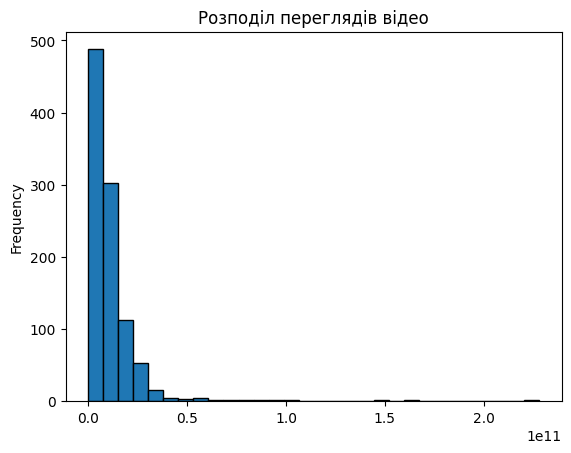

In [8]:
# 7. Побудуйте діаграму розподілу переглядів
df_yt['video views'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Розподіл переглядів відео')
plt.show()

In [9]:
# 8. Визначте максимальну, мінімальну, середню кількість переглядів
print("Max:", df_yt['video views'].max())
print("Min:", df_yt['video views'].min())
print("Mean:", df_yt['video views'].mean())

Max: 228000000000.0
Min: 0.0
Mean: 11039537052.03819


In [10]:
# 9. Країна, де найбільше відео було завантажено
country_uploads = df_yt.groupby('Country')['uploads'].sum().idxmax()
print("Країна з найбільшою кількістю завантажень:", country_uploads)

Країна з найбільшою кількістю завантажень: India


In [11]:
# 10. Відео (назва) з найбільшою та найменшою кількістю завантажень
print("Найбільше:", df_yt.loc[df_yt['uploads'].idxmax(), 'Title'])
print("Найменше:", df_yt.loc[df_yt['uploads'].idxmin(), 'Title'])

Найбільше: ABP NEWS
Найменше: Music


Завдання 2

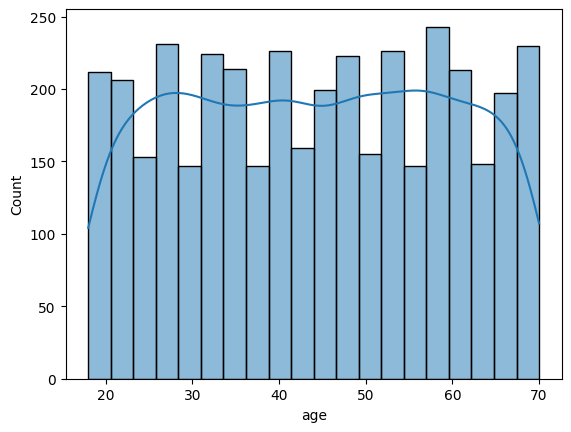

In [12]:
import seaborn as sns

df_shop = pd.read_csv('shopping_trends.csv')

# Перейменування стовпців
df_shop.columns = df_shop.columns.str.lower().str.replace(' ', '_')

# 1. Гістограма віку
sns.histplot(data=df_shop, x='age', bins=20, kde=True)
plt.show()

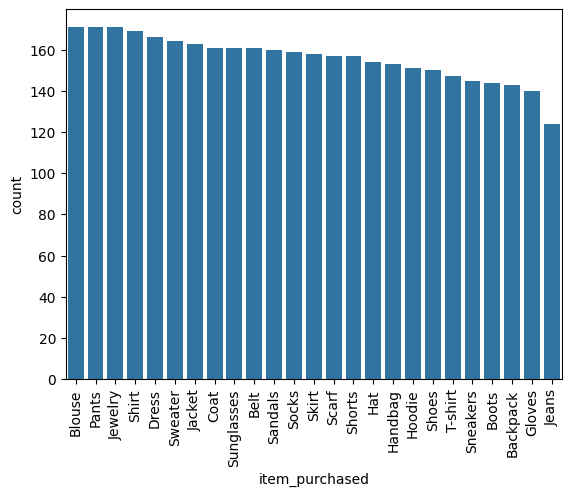

In [13]:
# 2. Порівняння розподілу покупок за статтею (item_purchased)
sns.countplot(data=df_shop, x='item_purchased', order=df_shop['item_purchased'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

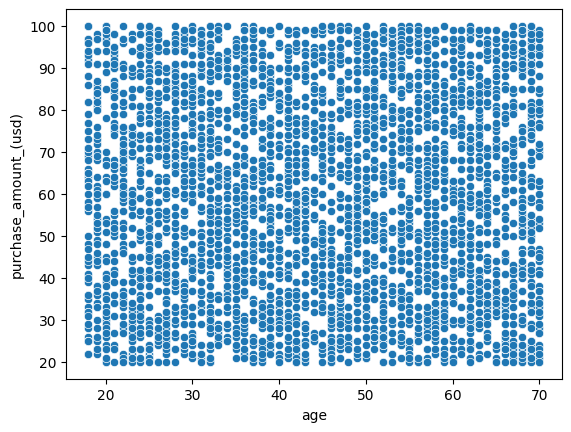

In [14]:
# 3. Залежність між віком та сумою покупок
sns.scatterplot(data=df_shop, x='age', y='purchase_amount_(usd)')
plt.show()

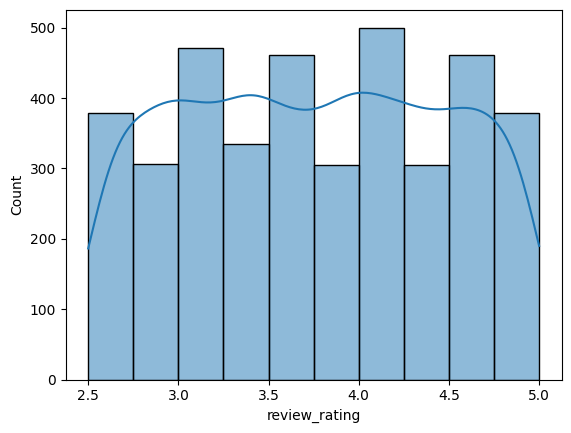

In [15]:
# 4. Графік розподілу оцінок товарів
sns.histplot(data=df_shop, x='review_rating', bins=10, kde=True)
plt.show()

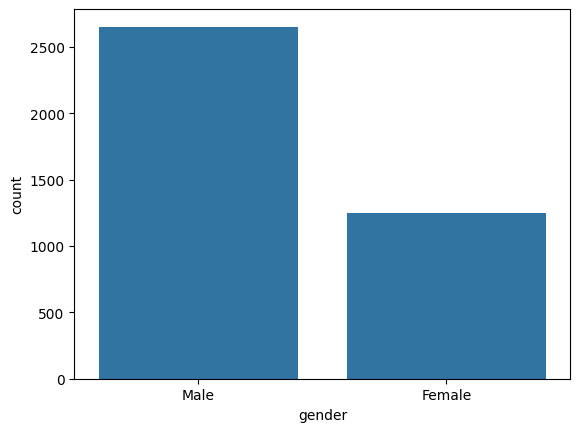

In [16]:
# 5. Категоріальна діаграма для статі
sns.countplot(data=df_shop, x='gender')
plt.show()

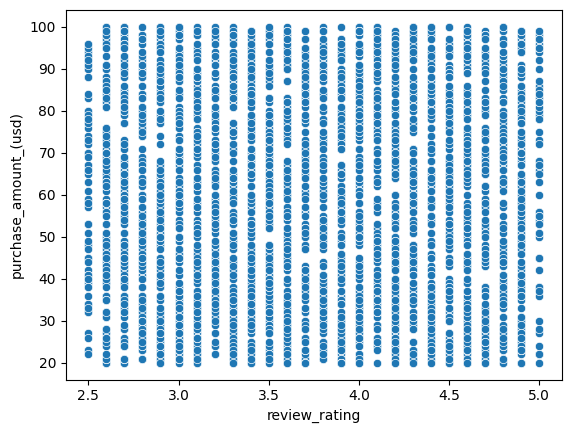

In [17]:
# 6. Залежність між рейтингом і сумою покупок
sns.scatterplot(data=df_shop, x='review_rating', y='purchase_amount_(usd)')
plt.show()

Завдання 3

In [24]:
import altair as alt
import plotly.express as px
from vega_datasets import data

# 1. Горизонтальна діаграма врожайності пшениці (Altair)
wheat = data.wheat()
bars = alt.Chart(wheat).mark_bar().encode(
    x='wheat:Q',
    y='year:O'
)
text = bars.mark_text(
    align='left',
    baseline='middle',
    dx=3
).encode(
    text='wheat:Q'
)
chart1 = (bars + text).properties(title='Врожайність пшениці за роками')
chart1.show()

alt.LayerChart(...)

In [23]:
# 2. Багатошарова діаграма виробництва електроенергії (Altair)
iowa = data.iowa_electricity()
chart2 = alt.Chart(iowa).mark_bar(opacity=0.7).encode(
    x='year:O',
    y='net_generation:Q',
    color='source:N'
).properties(title='Виробництво електроенергії в Айові')
chart2.show()

alt.Chart(...)

In [21]:
# 3. Графік Plotly для датасету Iris
iris = px.data.iris()
fig = px.scatter(
    iris,
    x="sepal_width",
    y="sepal_length",
    size="petal_length",
    color="species",
    hover_data=["petal_width"],
    title="Iris Dataset: Sepal Width vs Sepal Length"
)
fig.show()